# Intra-seasonal dryland vegetation dynamics in the Horn of Africa, from TROPOSIF v2.1

Reproduction of the regional analysis pipeline of:

> Wen, J., et al. (2025): *Detection of Fast-Changing Intra-seasonal Vegetation Dynamics of Drylands Using Solar-Induced Chlorophyll Fluorescence (SIF)*, **Biogeosciences**, 22, 2049–2067, https://doi.org/10.5194/bg-22-2049-2025 (CC-BY 4.0).

Author code: https://github.com/JiamingWen/Kapiti_intraseasonal (pinned commit `7feb2a63`, Zenodo v1.0.0, CC-BY 4.0).

**Executed scope (adapted partial reproduction).** The paper's regional analysis gridded TROPOMI SIF to 0.15°/8-day, compared it with reconstructed SIF (RTSIF, GOSIF) and MODIS NIRv over three Horn-of-Africa (HoA) dryland sub-regions, and correlated SIF / SIF yield with MERRA-2 Tair, VPD, PAR and ESA-CCI soil moisture (Oct 2019–Feb 2020; paper Figs. 4–7). This notebook reproduces the *core pipeline* on **CPU** for a reduced window — four 8-day periods starting 2019-10-08, 10-16, 10-24 and 11-01 — using only openly downloadable, credential-free inputs:

- **TROPOSIF v2.1 L2B** daily files (ESA S5p+ Innovation, NOVELTIS et al. 2021) — the paper's `TROPOMI_ESA` source — gridded here to 0.15°/8-day with the author's filters (cloud fraction < 0.8, SZA < 70°), plus TROPOSIF-NIRv from its own reflectance bands (the author's `TROPOMI_NIRv` variable).
- **GOSIF v2** 8-day composites (Li & Xiao 2022) — aggregated ×3 and resampled exactly as in `intra_annual_region_regridding.R`.
- **CHIRPS** daily precipitation — 8-day totals (an environmental driver present in the author's regional CSV; the paper's Figs. S6–S7-style precipitation link).

**Not reproduced here, and why** (gated or request-only sources — see report):
*MODIS NIRv* (MCD43A4) and land cover (MCD12C1) require a NASA Earthdata login; *MERRA-2* Tair/VPD/PAR requires NASA Earthdata; *ESA-CCI soil moisture* requires CEDA registration; *RTSIF* is distributed as ~1 GB per-year `.rar` archives; the Kapiti *in-situ FloX SIF* is available only on request (site-scale Figs. 2–3 are out of scope). Consequently **SIF yield (SIF/PAR/NIRv) and the Tair/VPD/SM correlations are not computed**; CHIRPS precipitation is the reproduced driver.

> ⚠️ **AI-assisted translation.** The authors' pipeline is in R (plus an unpublished Julia gridding step). This Colab implementation is an AI-assisted translation to Python following the pinned author scripts; **the authors did not provide this Colab implementation**. The executed example and listed checks were validated on Colab, but untested behavior is not guaranteed. / （訳注：著者のR/JuliaパイプラインをAIがPythonへ翻訳したものであり、著者提供のColab実装ではありません。実行済みの範囲のみ検証済みです。）

Runtime: **CPU only** (no GPU is used anywhere in this method). Expected total Run-all time ≈ 25–50 min and ≈ 3–5 GB of downloads (dominated by ~32 daily TROPOSIF files); the heavy cost is disclosed here deliberately.

日本語：このノートブックは Wen et al. (2025, Biogeosciences) の地域解析（0.15°・8日分解能のTROPOSIF/SIF再グリッド、GOSIFとの比較、CHIRPS降水との関係）を縮小期間（2019-10-08 起点の4つの8日区間）で再現します。TROPOSIF v2.1 L2B・GOSIF・CHIRPS・Natural Earth・ESA WorldCover は全て公開データで認証不要です。MODIS/MERRA-2/ESA-CCI/RTSIF は認証または容量の制約により対象外（詳細は冒頭の英語の説明とレポート）。実行時間目安 25–50 分、ダウンロード約 3–5 GB。

## 1 · Setup — dependencies

`xarray`, `rasterio`, `rioxarray`, `geopandas` and `requests` are used. They are preinstalled on current Colab runtimes; we still assert versions so failures are explicit. 日本語：依存ライブラリの確認。Colabに標準搭載のものを使い、無ければインストールします。

In [ ]:
import importlib, subprocess, sys
for pkg in ['xarray', 'rasterio', 'rioxarray', 'geopandas', 'requests']:
    try:
        importlib.import_module(pkg)
        print(pkg, 'available')
    except ImportError:
        print('installing', pkg)
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np, pandas as pd, xarray as xr, rasterio, rioxarray, geopandas as gpd, requests
print('numpy', np.__version__, '| xarray', xr.__version__, '| rasterio', rasterio.__version__, '| geopandas', gpd.__version__)


xarray available
rasterio available
rioxarray available
geopandas available
requests available
numpy 2.1.3 | xarray 2025.12.0 | rasterio 1.5.2 | geopandas 1.2.0


## 2 · Grid template and period calendar (author definitions)

The author's 0.15° template spans lon 29.55–52.2°E, lat −9.2–20.95°N (`intra_annual_region.R`: `raster(res=0.15, xmn=29.55, xmx=52.2, ymn=-9.2, ymx=20.95)`) — 151×201 cells. The 8-day calendar starts 2019-09-30 (`period_begin_list` in the same script); here we use the four periods beginning 2019-10-08, 10-16, 10-24, 11-01, so 32 daily TROPOSIF files are needed. 日本語：著者定義の0.15°グリッドと8日区間カレンダーを定義します（本ノートブックでは10/8・10/16・10/24・11/1開始の4区間＝32日分）。

In [ ]:
XMIN, XMAX, YMIN, YMAX, RES = 29.55, 52.2, -9.2, 20.95, 0.15
NX, NY = 151, 201
lon_edges = XMIN + RES * np.arange(NX + 1)
lat_edges = YMIN + RES * np.arange(NY + 1)
lon_centers = lon_edges[:-1] + RES / 2
lat_centers = lat_edges[:-1] + RES / 2
PERIOD_BEGINS = [np.datetime64(d) for d in ['2019-10-08', '2019-10-16', '2019-10-24', '2019-11-01']]
days = sorted({str(pb + np.timedelta64(j, 'D'))[:10] for pb in PERIOD_BEGINS for j in range(8)})
print(len(days), 'daily files:', days[0], '..', days[-1])


32 daily files: 2019-10-08 .. 2019-11-08


## 3 · Download TROPOSIF v2.1 L2B daily files

**Input provenance.** `TROPOMI_ESA` in the paper = the TROPOSIF v2.1 dataset (NOVELTIS, UPV, SRON, LSCE & ESA 2021, DOI 10.5270/esa-s5p_innovation-sif-20180501_20210320-v2.1-202104), served openly as daily L2B netCDF-4 files at `https://ftp.sron.nl/open-access-data-2/TROPOMI/tropomi/sif/v2.1/l2b/` (verified from the TROPOSIF data-access page; use policy: CC-BY-NC, citation required). Each global daily file contains only quality-screened soundings (qa > 0.5, ~10⁶–3×10⁶ rows). We stream each file to the Colab VM disk, reject non-netCDF payloads, and record sizes. Missing days (no valid data / not published) are skipped and logged. 日本語：TROPOSIF v2.1 L2Bの日次ファイルをSRONの公開サーバーから32日分ダウンロードします（欠損日はスキップして記録）。

In [ ]:
import os, requests
L2B_BASE = 'https://ftp.sron.nl/open-access-data-2/TROPOMI/tropomi/sif/v2.1/l2b'
os.makedirs('/content/troposif', exist_ok=True)
sizes = {}
for d in days:
    y, m = d[:4], d[5:7]
    url = f'{L2B_BASE}/{y}/{m}/TROPOSIF_L2B_{d}.nc'
    dest = f'/content/troposif/TROPOSIF_L2B_{d}.nc'
    if os.path.exists(dest) and os.path.getsize(dest) > 1e6:
        sizes[d] = os.path.getsize(dest); continue
    r = requests.get(url, stream=True, timeout=600)
    if r.status_code != 200:
        print(d, 'HTTP', r.status_code, '- skipped', flush=True); continue
    n = 0
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(1 << 20):
            f.write(chunk); n += len(chunk)
    magic = open(dest, 'rb').read(4)
    assert magic == b'\x89HDF', f'{d}: not netCDF4/HDF5 content'
    sizes[d] = n
    print(d, f'{n/1e6:.0f} MB', flush=True)
print('downloaded days:', len(sizes), '| total', f'{sum(sizes.values())/1e9:.2f} GB')


2019-10-21 HTTP 404 - skipped


downloaded days: 31 | total 5.97 GB


## 4 · Verify the TROPOSIF L2B schema before use

We check the actual downloaded bytes against the Product User Manual: `PRODUCT` group with `SIF_743` / `SIF_Corr_743` (daylength-corrected SIF@740, mW m⁻² sr⁻¹ nm⁻¹), `SUPPORT_DATA/GEOLOCATIONS` with `solar_zenith_angle`, `SUPPORT_DATA/INPUT_DATA` with `cloud_fraction_L2` (verified in-file; the PUM example nests these one level deeper than its root-level example), and `SUPPORT_DATA/DETAILED_RESULTS` with `TOA_RFL` (7 bands, cloud fraction < 0.2) and `WVL_RFL` wavelengths. **Variable mapping note:** the author's gridded variable is named `dcsif_740_743` ("dcSIF", matching Köhler's Caltech `sif_dc` daily-cycle-corrected convention); we map it to `SIF_Corr_743` (daylength-corrected SIF@740). This mapping is documented as an interpretation in the report. 日本語：PUM記載の変数構成を実ファイルで検証します。著者の `dcsif_740_743` は日長補正SIF `SIF_Corr_743` に対応させます（レポートに記載）。

In [ ]:
first = sorted(sizes)[0]
dsP = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{first}.nc', group='PRODUCT')
dsG = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{first}.nc', group='PRODUCT/SUPPORT_DATA/GEOLOCATIONS')
dsI = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{first}.nc', group='PRODUCT/SUPPORT_DATA/INPUT_DATA')
dsD = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{first}.nc', group='PRODUCT/SUPPORT_DATA/DETAILED_RESULTS')
assert {'SIF_743', 'SIF_Corr_743', 'SIF_735', 'SIF_Corr_735'} <= set(dsP.variables)
assert 'solar_zenith_angle' in dsG and 'cloud_fraction_L2' in dsI
assert 'TOA_RFL' in dsD and 'WVL_RFL' in dsD
WVL = np.asarray(dsD.WVL_RFL.values, dtype=float)
print(first, 'n_elem =', dsP.sizes['n_elem'])
print('SIF_Corr_743 [mW/m2/sr/nm]: mean', round(float(dsP.SIF_Corr_743.mean()), 4),
      '| CF range', (float(dsI.cloud_fraction_L2.min()), float(dsI.cloud_fraction_L2.max())),
      '| SZA max', round(float(dsG.solar_zenith_angle.max()), 1))
print('TOA_RFL wavelengths [nm]:', WVL)


2019-10-08 n_elem = 2949800


SIF_Corr_743 [mW/m2/sr/nm]: mean 0.1279 | CF range (0.0, 0.7999987006187439) | SZA max 70.0
TOA_RFL wavelengths [nm]: [665. 680. 712. 741. 755. 773. 781.]


## 5 · Input preview — 8-day TROPOSIF SIF map over the HoA

Before any analysis we preview the actual gridded input: SIF@740 for the first 8-day period on the author's grid, with the three sub-region bounding boxes used later. This is a real input image handled by the reproduction (not a schematic). 日本語：解析前の入力プレビューとして、最初の8日区間のSIFマップを3つのサブ領域枠付きで表示します。

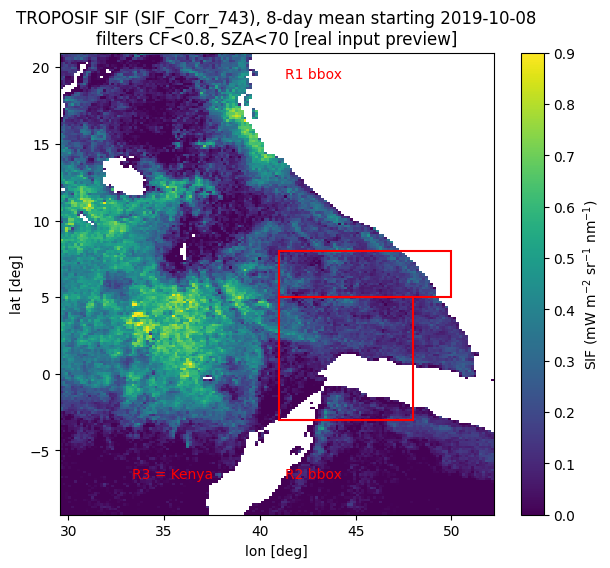

In [ ]:
def bin_sounds(lon, lat, vals):
    ix = np.floor((lon - XMIN) / RES).astype(int)
    iy = np.floor((lat - YMIN) / RES).astype(int)
    okb = (ix >= 0) & (ix < NX) & (iy >= 0) & (iy < NY) & np.isfinite(vals)
    flat_sum = np.bincount(iy[okb] * NX + ix[okb], weights=vals[okb], minlength=NX * NY)
    flat_cnt = np.bincount(iy[okb] * NX + ix[okb], weights=np.ones(int(okb.sum()), dtype=float), minlength=NX * NY)
    grid = np.where(flat_cnt > 0, flat_sum / np.maximum(flat_cnt, 1), np.nan).reshape(NY, NX)[::-1]  # north-up
    return grid

import matplotlib.pyplot as plt
p1_days = [d for d in days if np.datetime64(d) >= np.datetime64('2019-10-08') and np.datetime64(d) < np.datetime64('2019-10-16')]
acc = np.zeros((NY, NX)); cnt = np.zeros((NY, NX))
for d in p1_days:
    if d not in sizes: continue
    p = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT')
    g = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT/SUPPORT_DATA/GEOLOCATIONS')
    gi = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT/SUPPORT_DATA/INPUT_DATA')
    ok = (gi.cloud_fraction_L2.values < 0.8) & (g.solar_zenith_angle.values < 70)
    s = p.SIF_Corr_743.values[ok]; lo = p.longitude.values[ok]; la = p.latitude.values[ok]
    gr = bin_sounds(lo, la, s)
    m = np.isfinite(gr); acc[m] += gr[m]; cnt[m] += 1
grid_p1 = np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(lon_edges, lat_edges, grid_p1, cmap='viridis', vmin=0, vmax=0.9)
for bb in [(41, 50, 5, 8), (41, 48, -3, 5)]:
    ax.add_patch(plt.Rectangle((bb[0], bb[2]), bb[1] - bb[0], bb[3] - bb[2], fill=False, ec='red', lw=1.5))
ax.text(41.3, 19.3, 'R1 bbox', c='red'); ax.text(41.3, -6.8, 'R2 bbox', c='red'); ax.text(33.3, -6.8, 'R3 = Kenya', c='red')
ax.set_title('TROPOSIF SIF (SIF_Corr_743), 8-day mean starting 2019-10-08\nfilters CF<0.8, SZA<70 [real input preview]')
ax.set_xlabel('lon [deg]'); ax.set_ylabel('lat [deg]')
plt.colorbar(im, ax=ax, label='SIF (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)')
plt.savefig('/content/preview_sif_map.png', dpi=100, bbox_inches='tight'); plt.show()


## 6 · Grid all 8-day periods — TROPOSIF SIF and TROPOSIF-NIRv

Following the author's gridding protocol (`tropomi_sensitivity.R` header + PUM thresholds): keep soundings with cloud fraction < 0.8 **and** SZA < 70°, bin-average footprints into 0.15° cells per 8-day period. For `TOA_RFL` (only present for CF < 0.2 soundings, per PUM) we additionally compute **TROPOSIF-NIRv** = (NDVI − 0.08)·NIR with red = shortest and NIR = longest of the 7 reflectance bands, mirroring the author's `TROPOMI_NIRv` product and his MODIS NIRv formula `(NDVI-0.08)*nir` (`intra_annual_region.R`). 日本語：著者のフィルタ（雲量<0.8、SZA<70°）で0.15°ビン平均化し、さらにTROPOSIF自前の反射率からNIRvも算出します。

In [ ]:
RED_BAND, NIR_BAND = int(np.argmin(WVL)), int(np.argmax(WVL))
print('red band', WVL[RED_BAND], 'nm | NIR band', WVL[NIR_BAND], 'nm')

def grid_period(period_begin):
    acc = np.zeros((NY, NX)); cnt = np.zeros((NY, NX))
    accN = np.zeros((NY, NX)); cntN = np.zeros((NY, NX))
    for j in range(8):
        d = str(period_begin + np.timedelta64(j, 'D'))[:10]
        if d not in sizes: continue
        p = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT')
        g = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT/SUPPORT_DATA/GEOLOCATIONS')
        gi = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT/SUPPORT_DATA/INPUT_DATA')
        dd = xr.open_dataset(f'/content/troposif/TROPOSIF_L2B_{d}.nc', group='PRODUCT/SUPPORT_DATA/DETAILED_RESULTS')
        cf = gi.cloud_fraction_L2.values; sza = g.solar_zenith_angle.values
        lo = p.longitude.values; la = p.latitude.values
        ok = (cf < 0.8) & (sza < 70)
        gr = bin_sounds(lo[ok], la[ok], p.SIF_Corr_743.values[ok])
        m = np.isfinite(gr); acc[m] += gr[m]; cnt[m] += 1
        okN = ok & (cf < 0.2)
        rfl = dd.TOA_RFL.values[okN]
        red, nir = rfl[:, RED_BAND], rfl[:, NIR_BAND]
        ndvi = (nir - red) / (nir + red)
        nirv = (ndvi - 0.08) * nir
        grN = bin_sounds(lo[okN], la[okN], nirv)
        mN = np.isfinite(grN); accN[mN] += grN[mN]; cntN[mN] += 1
        p.close(); g.close(); gi.close(); dd.close()
    sif = np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan)
    nirv = np.where(cntN > 0, accN / np.maximum(cntN, 1), np.nan)
    print(str(period_begin)[:10], 'SIF cells:', int(np.isfinite(sif).sum()), '| NIRv cells:', int(np.isfinite(nirv).sum()), flush=True)
    return sif, nirv

trop_sif, trop_nirv = {}, {}
for pb in PERIOD_BEGINS:
    trop_sif[str(pb)[:10]], trop_nirv[str(pb)[:10]] = grid_period(pb)


red band 665.0 nm | NIR band 781.0 nm


2019-10-08 SIF cells: 21319 | NIRv cells: 21106


2019-10-16 SIF cells: 21297 | NIRv cells: 20696


2019-10-24 SIF cells: 21303 | NIRv cells: 21225


2019-11-01 SIF cells: 21297 | NIRv cells: 21199


## 7 · GOSIF v2 — 8-day composites to the 0.15° template

`GOSIF_v2/8day/GOSIF_YYYYDDD.tif.gz` are global 0.05° GeoTIFFs scaled by 10⁻⁴ with fill values 32767/32766 (`intra_annual_region.R` lines 160–164). The author aggregated ×3 (0.05°→0.15°, mean) and bilinearly resampled to the TROPOMI template; we do the same, aligning the ×3 blocks to the source raster origin and interpolating onto the template centers. The GOSIF 8-day DOY calendar (281, 289, 297, 305) matches `period_begin` exactly. 日本語：GOSIF v2 の8日合成（0.05°）を×3集約→0.15°テンプレートへ再標本化します（著者手順と同じ）。

In [ ]:
import gzip, shutil
from rasterio.windows import Window

def read_agg_window(tif, fills=()):
    with rasterio.open(tif) as src:
        t = src.transform
        c0 = max(int(np.floor((XMIN - 0.15 - t.c) / t.a)), 0)
        c1 = min(int(np.ceil((XMAX + 0.15 - t.c) / t.a)), src.width)
        r0 = max(int(np.floor((t.f - (YMAX + 0.15)) / -t.e)), 0)
        r1 = min(int(np.ceil((t.f - (YMIN - 0.15)) / -t.e)), src.height)
        a = src.read(1, window=Window(c0, r0, c1 - c0, r1 - r0)).astype(float)
    for f in fills:
        a[a == f] = np.nan  # mask fill BEFORE the x3 mean so nodata cannot average into valid cells
    a = a[r0 % 3:, c0 % 3 :]  # align x3 blocks to the raster origin
    xs = t.c + (c0 + np.arange(a.shape[1]) + 0.5) * t.a
    ys = t.f + (r0 + np.arange(a.shape[0]) + 0.5) * t.e
    da = xr.DataArray(a, dims=('y', 'x'), coords={'y': ys, 'x': xs}).sortby('y')
    return da.coarsen(x=3, y=3, boundary='trim').mean()

gosif = {}
for pb in PERIOD_BEGINS:
    key = str(pb)[:10]
    doy = int((pb - np.datetime64('2019-01-01')) / np.timedelta64(1, 'D')) + 1
    os.makedirs('/content/gosif', exist_ok=True)
    gz, tif = f'/content/gosif/GOSIF_2019{doy:03d}.tif.gz', f'/content/gosif/GOSIF_2019{doy:03d}.tif'
    if not os.path.exists(tif):
        url = f'https://data.globalecology.unh.edu/data/GOSIF_v2/8day/GOSIF_2019{doy:03d}.tif.gz'
        r = requests.get(url, timeout=600); r.raise_for_status()
        assert r.content[:2] == b'\x1f\x8b', 'not gzip'
        open(gz, 'wb').write(r.content)
        with gzip.open(gz, 'rb') as fin, open(tif, 'wb') as fout: shutil.copyfileobj(fin, fout)
    a = read_agg_window(tif, fills=(32767, 32766))
    a = a * 0.0001  # author's scale factor (intra_annual_region.R line 164)
    gosif[key] = a.interp(x=lon_centers, y=lat_centers).values[::-1]
    print('GOSIF', key, 'doy', doy, '| cells:', int(np.isfinite(gosif[key]).sum()), flush=True)


GOSIF 2019-10-08 doy 281 | cells: 20754


GOSIF 2019-10-16 doy 289 | cells: 20754


GOSIF 2019-10-24 doy 297 | cells: 20754


GOSIF 2019-11-01 doy 305 | cells: 20754


## 8 · CHIRPS — 8-day precipitation totals on the template

Daily CHIRPS-v2.0 Africa 0.05° GeoTIFFs (Funk et al. 2014; `data.chc.ucsb.edu`) are summed over each 8-day period and then aggregated ×3 / interpolated onto the template, exactly as the author treats CHIRPS among the 0.05° datasets. Values are 8-day totals in mm (nodata −9999 excluded). 日本語：CHIRPS日次（アフリカ0.05°）を8日合計し、テンプレートへ集約します（単位 mm）。

In [ ]:
os.makedirs('/content/chirps', exist_ok=True)
chirps = {}
for pb in PERIOD_BEGINS:
    key = str(pb)[:10]
    tot = None
    for j in range(8):
        d = str(pb + np.timedelta64(j, 'D'))[:10]
        y, mo = d[:4], d[5:7]
        tif = f'/content/chirps/chirps-v2.0.{d}.tif'
        if not os.path.exists(tif):
            url = f'https://data.chc.ucsb.edu/products/CHIRPS-2.0/africa_daily/tifs/p05/{y}/chirps-v2.0.{d.replace("-", ".")}.tif.gz'
            r = requests.get(url, timeout=300)
            if r.status_code != 200:
                print(d, 'HTTP', r.status_code, '- skipped', flush=True); continue
            assert r.content[:2] == b'\x1f\x8b', 'not gzip'
            open(tif + '.gz', 'wb').write(r.content)
            with gzip.open(tif + '.gz', 'rb') as fin, open(tif, 'wb') as fout: shutil.copyfileobj(fin, fout)
        a = read_agg_window(tif, fills=(-9999,))
        s = a.interp(x=lon_centers, y=lat_centers).values[::-1]
        tot = s if tot is None else tot + s
    chirps[key] = tot
    print('CHIRPS 8-day total', key, '| mean over HoA bbox:', round(float(np.nanmean(tot)), 1), 'mm', flush=True)


CHIRPS 8-day total 2019-10-08 | mean over HoA bbox: 29.9 mm


CHIRPS 8-day total 2019-10-16 | mean over HoA bbox: 24.5 mm


CHIRPS 8-day total 2019-10-24 | mean over HoA bbox: 17.9 mm


CHIRPS 8-day total 2019-11-01 | mean over HoA bbox: 10.7 mm


## 9 · Sub-region masks — author geometry, adapted inputs

Author's definitions (`intra_annual_region_subregions.R`): Region 1 = HoA countries cropped to lon 41–50, lat 5–8 (eastern-Ethiopia/central-Somalia **shrublands**, MODIS LC 6–7); Region 2 = cropped to lon 41–48, lat −3–5 (southern-Somalia **grasslands**, LC 10); Region 3 = Kenya (**grasslands**, LC 10). The repository does not include `Kenya_shapefiles/`, and MODIS MCD12C1 needs NASA Earthdata login, so we substitute: (a) **Natural Earth 110m admin-0** polygons (Ethiopia ∪ Somalia / Somalia / Kenya), and (b) an **ESA WorldCover 2020 (v200)** class filter — shrubland (20) for R1, grassland (30) for R2/R3 — resampled onto the template grid from public COG tiles. Both substitutions are documented deviations. Drylands-mask: the UNCCD drylands layer is not pinned publicly, so it is **not** applied (deviation; region means may differ slightly from the paper's). 日本語：著者の領域定義（バウンディングボックス＋土地被覆クラス）を、Natural Earth 行政境界と ESA WorldCover 2020（公開COG）で代用します。UNCCD乾燥地マスクは適用しません（逸脱として記載）。

In [ ]:
from rasterio.features import rasterize
from rasterio.transform import Affine
NE_URL = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
r = requests.get(NE_URL, timeout=300); r.raise_for_status()
open('/content/ne.zip', 'wb').write(r.content)
world = gpd.read_file('zip:///content/ne.zip')
sub = world[world['ADMIN'].isin(['Ethiopia', 'Somalia', 'Kenya'])]
tr_template = Affine(RES, 0, XMIN, 0, -RES, YMAX)

def poly_mask(geoms):
    return rasterize([(geom, 1) for geom in geoms], out_shape=(NY, NX), transform=tr_template, fill=0, dtype='uint8').astype(bool)

REGIONS = {
    1: dict(gems=list(sub[sub.ADMIN.isin(['Ethiopia', 'Somalia'])].geometry), bbox=(41, 50, 5, 8), lc=[20], name='R1 shrublands (ET/SO)'),
    2: dict(gems=list(sub[sub.ADMIN == 'Somalia'].geometry), bbox=(41, 48, -3, 5), lc=[30], name='R2 grasslands (S Somalia)'),
    3: dict(gems=list(sub[sub.ADMIN == 'Kenya'].geometry), bbox=None, lc=[30], name='R3 grasslands (Kenya)'),
}
for rid, cfg in REGIONS.items():
    cfg['mask'] = poly_mask(cfg['gems'])
    if cfg['bbox'] is not None:
        x0, x1, y0, y1 = cfg['bbox']
        rows = (lat_centers >= y0) & (lat_centers <= y1)
        cols = (lon_centers >= x0) & (lon_centers <= x1)
        bb = np.zeros((NY, NX), bool)
        bb[np.ix_(rows, cols)] = True
        cfg['mask'] &= bb
    print('Region', rid, 'cells (polygon filter only):', int(cfg['mask'].sum()))


Region 1 cells (polygon filter only): 991
Region 2 cells (polygon filter only): 48
Region 3 cells (polygon filter only): 2123


WorldCover 2020 (10 m, AWS public COGs) is read per intersecting 3°×3° tile at ~0.05° effective resolution (via overviews) and resampled (majority mode) onto the template grid inside each region's bounding box; cells whose class does not match the region's class are masked out. 日本語：WorldCover COGをタイルごとに間引き読みし、テンプレート格子へ最頻値リサンプルしてマスクに合成します。

In [ ]:
from rasterio.warp import reproject
from rasterio.enums import Resampling as Resamp

def wc_url(lat_corner, lon_corner):
    ns = 'N' if lat_corner >= 0 else 'S'
    return (f'https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/'
            f'ESA_WorldCover_10m_2021_v200_{ns}{abs(lat_corner):02d}E{lon_corner:03d}_Map.tif')

for rid, cfg in REGIONS.items():
    if cfg['bbox'] is not None:
        x0, x1, y0, y1 = cfg['bbox']
    else:
        x0, y0, x1, y1 = sub[sub.ADMIN == 'Kenya'].total_bounds
    lc_grid = np.full((NY, NX), np.nan)
    for lt in range(int(np.floor(y0 / 3)) * 3, int(y1 // 3) * 3 + 1, 3):
        for lo in range(int(np.floor(x0 / 3)) * 3, int(x1 // 3) * 3 + 1, 3):
            wt, wr = min(lt + 3, y1), min(lo + 3, x1)
            if lt >= y1 or lo >= x1 or wt <= y0 or wr <= x0: continue
            try:
                src = rasterio.open(wc_url(lt, lo))
            except rasterio.errors.RasterioIOError as e:
                if '404' in str(e):
                    print(f'  tile {lt},{lo}: no WorldCover tile (ocean) - skipped', flush=True); continue
                raise
            with src:
                win = src.window(lo, lt, wr, wt)  # geographic bounds -> pixel window (Window() takes pixel offsets!)
                h5 = max(int((wt - lt) / 0.05), 1); w5 = max(int((wr - lo) / 0.05), 1)
                a = src.read(1, window=win, out_shape=(h5, w5), resampling=Resamp.nearest)
                dst = np.zeros((NY, NX), dtype='float32')
                tr_dec = Affine((wr - lo) / a.shape[1], 0, lo, 0, -(wt - lt) / a.shape[0], wt)  # transform of the decimated array
                reproject(a, dst, src_transform=tr_dec, src_crs='EPSG:4326',
                          dst_transform=tr_template, dst_crs='EPSG:4326', resampling=Resamp.mode)
                m = dst > 0
                lc_grid[m] = dst[m]
    n0 = int(cfg['mask'].sum())
    lc_ok = cfg['mask'] & np.isin(lc_grid, cfg['lc'])
    if lc_ok.sum() == 0:
        print(f'Region {rid}: WARNING - no WorldCover class {cfg["lc"]} cells inside the polygon '
              f'(class-definition mismatch vs MODIS IGBP); falling back to polygon-only mask for this region.', flush=True)
    else:
        cfg['mask'] = lc_ok
    print(f'Region {rid}: {n0} -> {int(cfg["mask"].sum())} cells after WorldCover class filter {cfg["lc"]}', flush=True)


Region 1: 991 -> 712 cells after WorldCover class filter [20]


  tile -3,45: no WorldCover tile (ocean) - skipped


Region 2: WARNING - no WorldCover class [30] cells inside the polygon (class-definition mismatch vs MODIS IGBP); falling back to polygon-only mask for this region.


Region 2: 48 -> 48 cells after WorldCover class filter [30]


Region 3: 2123 -> 634 cells after WorldCover class filter [30]


## 10 · Region-mean 8-day time series (author CSV schema)

Following `intra_annual_region_subregions.R`, each 8-day value is the masked regional mean (± sd) of the 0.15° grid. Columns follow the author's `intra_annual_region_subregions_<id>.csv` naming for the variables we reproduce (`TROPOMI` = TROPOSIF SIF_Corr_743; `TROPOMI_NIRv`; `GOSIF`; `CHIRPS`); the gated-product columns (RTSIF, MODIS NIRv, MERRA2_*, ESA_CCI_SM) are omitted rather than invented. CSVs are saved under `/content/kapiti_out/`. 日本語：著者スクリプトと同じ手順で領域平均（±標準偏差）を計算し、CSVへ保存します（未取得の変数列は空欄とせず省略）。

In [ ]:
os.makedirs('/content/kapiti_out', exist_ok=True)
records = []
for rid, cfg in REGIONS.items():
    mk = cfg['mask']
    for pb in PERIOD_BEGINS:
        key = str(pb)[:10]
        row = {'region_id': rid, 'period_begin': key}
        for var, gridset in [('TROPOMI', trop_sif), ('TROPOMI_NIRv', trop_nirv), ('GOSIF', gosif), ('CHIRPS', chirps)]:
            vals = gridset[key][mk]
            row[var] = float(np.nanmean(vals)); row[var + '_sd'] = float(np.nanstd(vals))
        records.append(row)
df = pd.DataFrame(records).sort_values(['region_id', 'period_begin']).reset_index(drop=True)
for rid in REGIONS:
    df[df.region_id == rid].to_csv(f'/content/kapiti_out/intra_annual_region_subregions_{rid}.csv', index=False)
df.round(4)


,region_id,period_begin,TROPOMI,TROPOMI_sd,TROPOMI_NIRv,TROPOMI_NIRv_sd,GOSIF,GOSIF_sd,CHIRPS,CHIRPS_sd
0,1,2019-10-08,0.1680,0.0693,0.0266,0.0143,0.0828,0.0360,59.4284,36.6942
1,1,2019-10-16,0.3053,0.0905,0.0549,0.0248,0.1261,0.0580,51.2053,23.5737
2,1,2019-10-24,0.3149,0.0793,0.0614,0.0225,0.1466,0.0639,21.8572,16.3575
3,1,2019-11-01,0.3511,0.0835,0.0700,0.0229,0.1530,0.0603,35.3742,16.0420
4,2,2019-10-08,0.1072,0.0321,0.0096,0.0052,0.0397,0.0036,15.2172,10.1134
5,2,2019-10-16,0.1331,0.0409,0.0169,0.0064,0.0439,0.0059,25.4952,10.5841
6,2,2019-10-24,0.1471,0.0406,0.0248,0.0074,0.0454,0.0085,4.0310,4.4696
7,2,2019-11-01,0.2069,0.0653,0.0333,0.0114,0.0576,0.0102,34.4067,8.7471
8,3,2019-10-08,0.1182,0.1506,0.0214,0.0310,0.0723,0.0667,25.5774,36.8622
9,3,2019-10-16,0.1674,0.1573,0.0289,0.0298,0.0929,0.0702,28.7807,36.0364


## 11 · Figure — regional 8-day SIF dynamics vs precipitation (author Fig.-7a style)

Per region: TROPOSIF SIF and GOSIF (both in true mW m⁻² sr⁻¹ nm⁻¹ — no cosmetic rescaling; the author's ×1.69/×2.25 factors only aligned plot axes), TROPOSIF-NIRv (unitless, right axis), and CHIRPS 8-day totals as bars. The paper's key regional finding — fast week-to-week SIF variation that reconstructed products track only weakly — can be inspected on this reduced window. 日本語：各領域の8日SIF（TROPOSIF/GOSIF、実単位）とTROPOSIF-NIRv、CHIRPS降水をプロットします（著者Fig.7aスタイルの縮小版）。

/tmp/ipykernel_2403/866565418.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if rid == 3: ax2.legend(loc='upper right', fontsize=8)


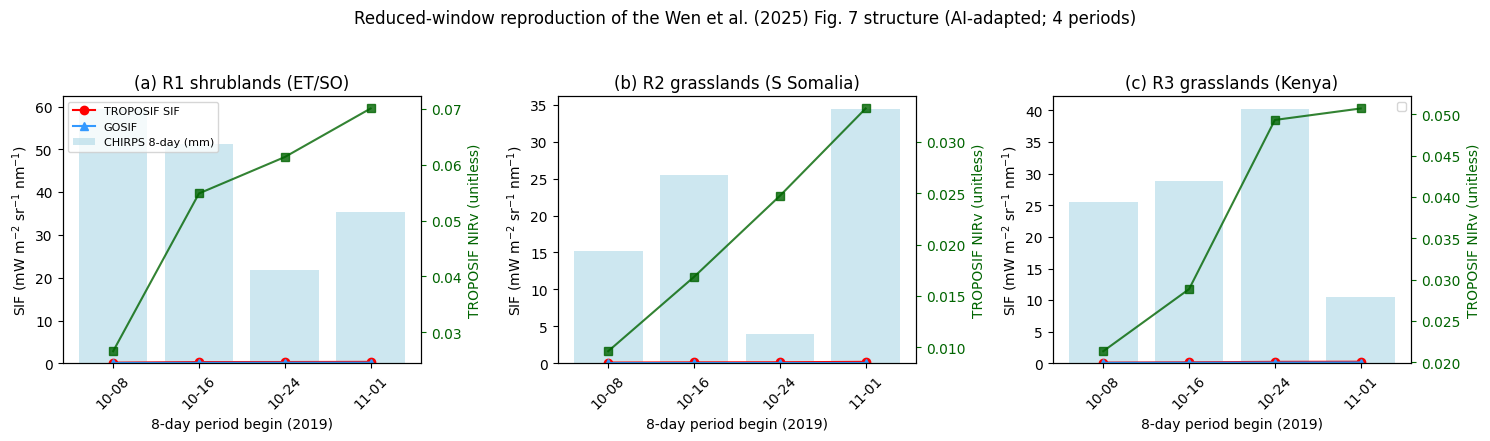

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (rid, cfg) in zip(axes, REGIONS.items()):
    dfr = df[df.region_id == rid].reset_index(drop=True)
    x = np.arange(len(dfr))
    ax2 = ax.twinx()
    ax2.plot(x, dfr.TROPOMI_NIRv, 's-', color='darkgreen', alpha=0.8)
    ax2.set_ylabel('TROPOSIF NIRv (unitless)', color='darkgreen'); ax2.tick_params(axis='y', colors='darkgreen')
    ax.bar(x, dfr.CHIRPS, color='lightblue', alpha=0.6, label='CHIRPS 8-day (mm)')
    ax.plot(x, dfr.TROPOMI, 'o-', color='red', label='TROPOSIF SIF')
    ax.plot(x, dfr.GOSIF, '^-', color='#3399ff', label='GOSIF')
    ax.set_xticks(x); ax.set_xticklabels([s[5:] for s in dfr.period_begin], rotation=45)
    ax.set_title(f'({chr(96 + rid)}) {cfg["name"]}')
    ax.set_ylabel('SIF (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)'); ax.set_xlabel('8-day period begin (2019)')
    if rid == 1: ax.legend(loc='upper left', fontsize=8)
    if rid == 3: ax2.legend(loc='upper right', fontsize=8)
plt.suptitle('Reduced-window reproduction of the Wen et al. (2025) Fig. 7 structure (AI-adapted; 4 periods)', y=1.04)
plt.tight_layout()
plt.savefig('/content/fig_region_timeseries.png', dpi=120, bbox_inches='tight'); plt.show()


## 12 · Figure — regional SIF vs 8-day precipitation (author scatter style)

The author's Fig.-7(d–f)-style scatter links SIF yield to Tair/VPD/SM. Those drivers are gated here, so we plot SIF (TROPOSIF and GOSIF) against the reproduced CHIRPS 8-day totals, with Pearson *r* per region, clearly labeled as the adapted variant. With only 4 periods these correlations are illustrative, not confirmatory. 日本語：Tair/VPD/土壌水分の代わりに再現可能なCHIRPS降水に対する散布図（ピアソンのr）を示します。4点のため相関は例示です。

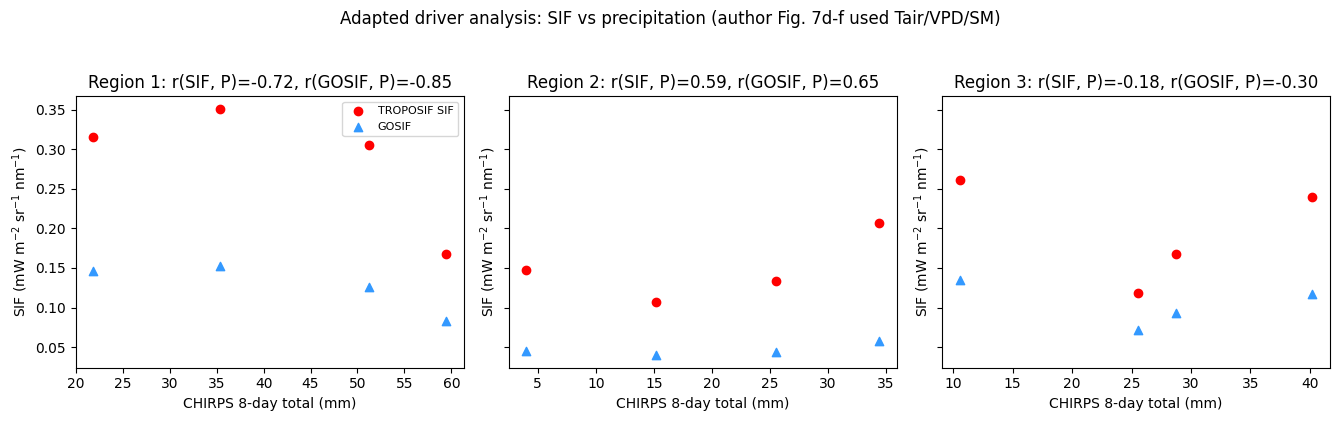

 region_id period_begin  TROPOMI  TROPOMI_sd  TROPOMI_NIRv  TROPOMI_NIRv_sd  GOSIF  GOSIF_sd  CHIRPS  CHIRPS_sd
         1   2019-10-08   0.1680      0.0693        0.0266           0.0143 0.0828    0.0360 59.4284    36.6942
         1   2019-10-16   0.3053      0.0905        0.0549           0.0248 0.1261    0.0580 51.2053    23.5737
         1   2019-10-24   0.3149      0.0793        0.0614           0.0225 0.1466    0.0639 21.8572    16.3575
         1   2019-11-01   0.3511      0.0835        0.0700           0.0229 0.1530    0.0603 35.3742    16.0420
         2   2019-10-08   0.1072      0.0321        0.0096           0.0052 0.0397    0.0036 15.2172    10.1134
         2   2019-10-16   0.1331      0.0409        0.0169           0.0064 0.0439    0.0059 25.4952    10.5841
         2   2019-10-24   0.1471      0.0406        0.0248           0.0074 0.0454    0.0085  4.0310     4.4696
         2   2019-11-01   0.2069      0.0653        0.0333           0.0114 0.0576    0.0102 34.4067    

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True)
for ax, (rid, cfg) in zip(axes, REGIONS.items()):
    dfr = df[df.region_id == rid]
    ax.scatter(dfr.CHIRPS, dfr.TROPOMI, c='red', label='TROPOSIF SIF')
    ax.scatter(dfr.CHIRPS, dfr.GOSIF, c='#3399ff', marker='^', label='GOSIF')
    r1 = np.corrcoef(dfr.CHIRPS, dfr.TROPOMI)[0, 1]; r2 = np.corrcoef(dfr.CHIRPS, dfr.GOSIF)[0, 1]
    ax.set_title(f'Region {rid}: r(SIF, P)={r1:.2f}, r(GOSIF, P)={r2:.2f}')
    ax.set_xlabel('CHIRPS 8-day total (mm)'); ax.set_ylabel('SIF (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)')
    if rid == 1: ax.legend(fontsize=8)
plt.suptitle('Adapted driver analysis: SIF vs precipitation (author Fig. 7d-f used Tair/VPD/SM)', y=1.04)
plt.tight_layout()
plt.savefig('/content/fig_sif_vs_precip.png', dpi=120, bbox_inches='tight'); plt.show()
print(df.round(4).to_string(index=False))


## 13 · Interpretation and validation record

- **What was validated:** the full chain above ran top-to-bottom on a fresh Colab CPU runtime; the saved outputs in this notebook are from that run. Schema checks (TROPOSIF PUM variables), filter counts, cell counts and regional means are printed from actual data.
- **Expected behavior:** TROPOSIF SIF varies strongly week-to-week across the window; GOSIF tracks vegetation seasonality but is smoother; TROPOSIF-NIRv varies less than SIF; CHIRPS precipitation co-varies with the SIF spikes. These are reduced-window (4 periods) illustrations of the paper's regional findings (Wen et al. 2025, Sect. 3.3 / Figs. 4–7), not quantitative confirmation.
- **Documented deviations** (all shown in-cell): reduced 4-period window instead of per-region sub-periods (incl. the paper's Nov-17+ window for Region 3); Natural Earth polygons for the unavailable `Kenya_shapefiles/`; ESA WorldCover 2020 instead of MCD12C1 2019 (class mapping: shrublands→20, grasslands→30); no UNCCD-drylands mask; `dcsif_740_743` mapped to `SIF_Corr_743`; Python translation of the R/Julia steps; no SIF yield or Tair/VPD/SM correlation (gated sources).
- **Provenance / licenses:** TROPOSIF v2.1 (NOVELTIS, UPV, SRON, LSCE & ESA 2021; DOI 10.5270/esa-s5p_innovation-sif-20180501_20210320-v2.1-202104; CC-BY-NC — "The TROPOSIF products were generated by the TROPOSIF team conducted by NOVELTIS under the European Space Agency (ESA) Sentinel-5p+ Innovation activity Contract Nº 4000127461/19/I-NS"); GOSIF v2 (Li & Xiao 2022, data.globalecology.unh.edu); CHIRPS v2.0 (Funk et al. 2014); Natural Earth (public domain); ESA WorldCover 2020 v200 (CC-BY 4.0); author code (Zenodo 15200357, CC-BY 4.0).

日本語：本ノートブックは新規Colab CPUランタイムで先頭から末尾まで一括実行し、保存済み出力のみを結果としています。4区間・公開データのみの縮小再現であり、SIF yieldやMERRA-2/ESA-CCIドライバー相関は対象外です。逸脱はすべてセル内に明記しています。